<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Mastering_Density_Plots_in_ggplot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mastering Density Plots: A Smooth Guide to Data Distribution

### নোটবুক পরিচিতি (Metadata)

- Aim: আর (R) এবং ggplot2 ব্যবহার করে ডেটার ডিস্ট্রিবিউশন বা বিন্যাসকে একটি মসৃণ (Smooth) কার্ভের মাধ্যমে উপস্থাপন করা শেখা।
- Level: Complete Beginner.
- Dataset: বিল্ট-ইন iris ডাটাসেট।
- Key Topics: ডেনসিটি প্লট বনাম হিস্টোগ্রাম, কালার কাস্টমাইজেশন, গ্রুপ ডেনসিটি এবং ব্যান্ডউইডথ অ্যাডজাস্টমেন্ট।

#### ডেনসিটি প্লট কেন ব্যবহার করবেন?
- ১. কন্টিনিউয়াস ডেটার ডিস্ট্রিবিউশন বোঝার জন্য।
- ২. একাধিক গ্রুপের মধ্যে ডিস্ট্রিবিউশনের তুলনা করতে।
- ৩. হিস্টোগ্রামের একটি "স্মুদার" অল্টারনেটিভ হিসেবে।
- ৪. বড় ডাটাসেটের প্যাটার্ন সহজে দেখার জন্য।

### ১. বেসিক ডেনসিটি প্লট (The Starting Point)
ডেনসিটি প্লট ডেটার ঘনত্ব বা প্রবাবিলিটি ডেনসিটি ফাংশন (PDF) দেখায়।

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


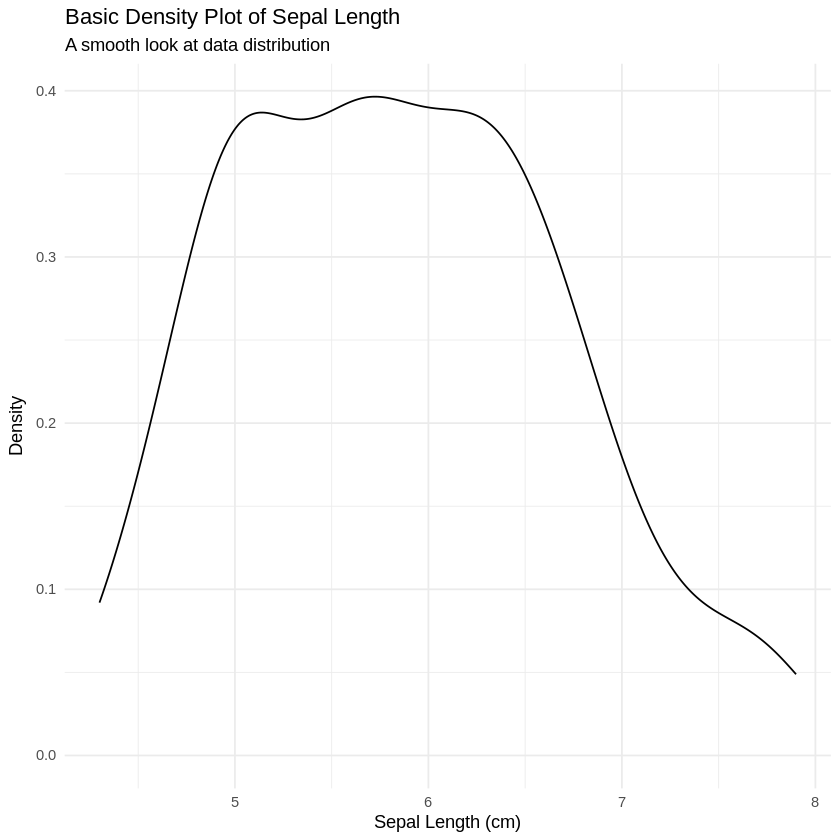

In [1]:
library(tidyverse)

# সাধারণ ডেনসিটি প্লট
iris %>%
  ggplot(aes(x = Sepal.Length)) +
  geom_density() +
  labs(title = "Basic Density Plot of Sepal Length",
       subtitle = "A smooth look at data distribution",
       x = "Sepal Length (cm)",
       y = "Density") +
  theme_minimal()

__ব্যাখ্যা:__ geom_density() ফাংশনটি স্বয়ংক্রিয়ভাবে ডেটার ডিস্ট্রিবিউশন ক্যালকুলেট করে একটি রেখা তৈরি করে।

### ২. ডেনসিটি প্লট কাস্টমাইজেশন (Styling)
শুধু একটি রেখা দেখার চেয়ে রঙ এবং স্বচ্ছতা যোগ করলে গ্রাফটি আরও ইনফরমেটিভ হয়।

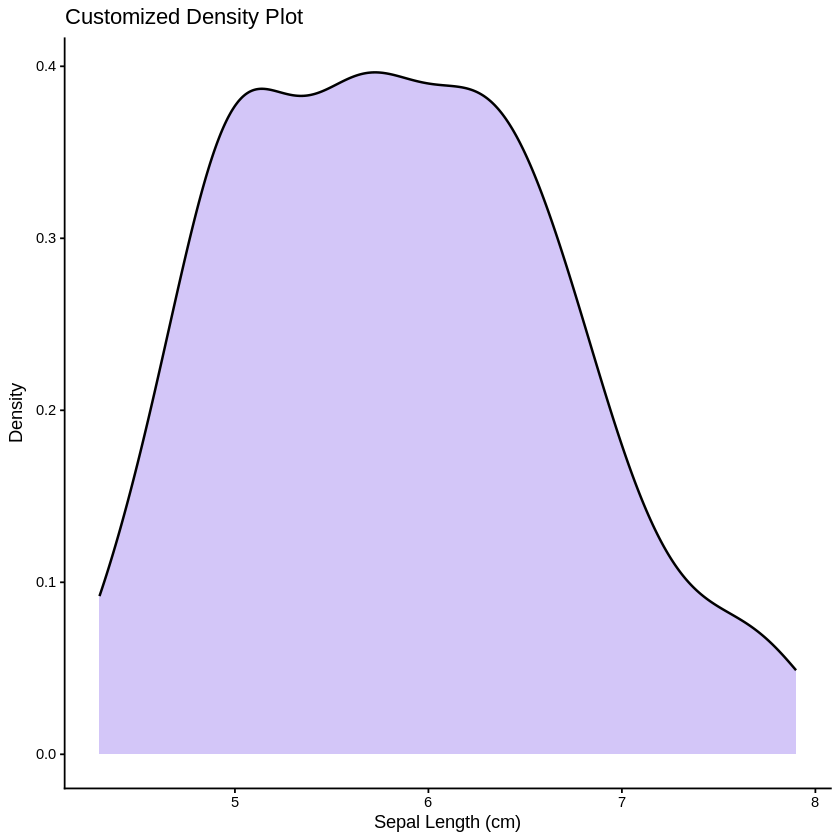

In [2]:
iris %>%
  ggplot(aes(Sepal.Length)) +
  geom_density(fill = "#A88EF2",         # ভেতরের রঙ
               alpha = 0.5,              # স্বচ্ছতা (০ থেকে ১)
               color = "black",          # বর্ডার রেখার রঙ
               linewidth = 0.7) +        # রেখার পুরুত্ব
  labs(title = "Customized Density Plot",
       x = "Sepal Length (cm)",
       y = "Density") +
  theme_classic()

__ব্যাখ্যা:__ fill দিয়ে আমরা এরিয়াটি ভরাট করেছি এবং alpha ব্যবহার করেছি যেন রঙটি হালকা দেখায়।

### ৩. গ্রুপ ভিত্তিক তুলনা (Multiple Densities)
যখন আমাদের কাছে একাধিক প্রজাতি (Species) থাকে, তখন তাদের ডিস্ট্রিবিউশন তুলনা করা সবচেয়ে কার্যকর।

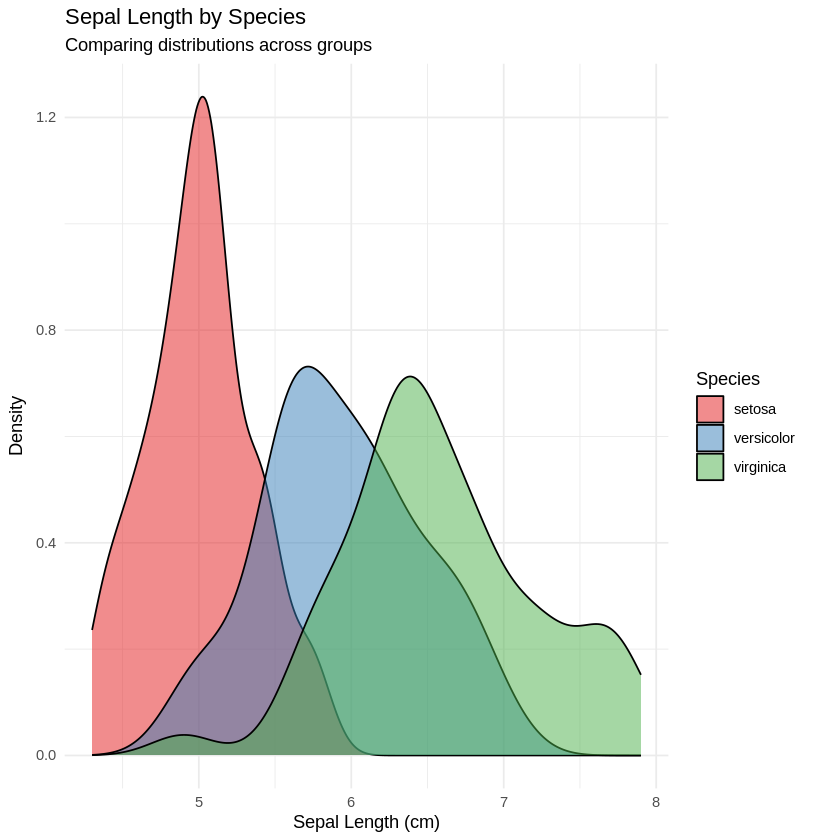

In [3]:
iris %>%
  ggplot(aes(Sepal.Length, fill = Species)) +
  geom_density(alpha = 0.5) +
  labs(title = "Sepal Length by Species",
       subtitle = "Comparing distributions across groups",
       x = "Sepal Length (cm)",
       y = "Density") +
  scale_fill_brewer(palette = "Set1") + # সুন্দর কালার প্যালেট
  theme_minimal()

__ব্যাখ্যা:__ aes() এর ভেতর fill = Species দেওয়ায় আর (R) প্রতিটি প্রজাতির জন্য আলাদা রঙের ডেনসিটি কার্ভ তৈরি করেছে। alpha এখানে অপরিহার্য, নাহলে একটি গ্রাফের নিচে অন্যটি ঢেকে যেত।

### ৪. স্মুথনেস কন্ট্রোল (Adjusting Bandwidth)
ডেনসিটি প্লট কতটা নিখুঁত বা কতটা মসৃণ হবে তা adjust প্যারামিটার দিয়ে নিয়ন্ত্রণ করা যায়।

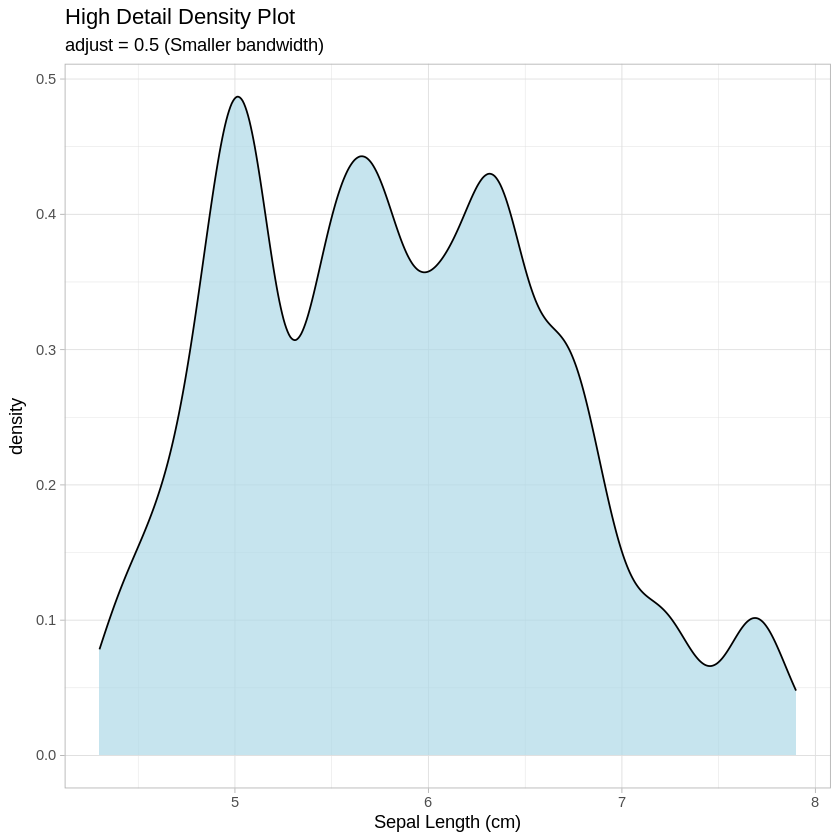

In [4]:
iris %>%
  ggplot(aes(Sepal.Length)) +
  geom_density(adjust = 0.5,               # ছোট মান মানে বেশি ডিটেইল (বেশি ঢেউ)
               fill = "lightblue",
               alpha = 0.7) +
  labs(title = "High Detail Density Plot",
       subtitle = "adjust = 0.5 (Smaller bandwidth)",
       x = "Sepal Length (cm)") +
  theme_light()

__ব্যাখ্যা:__ adjust এর মান ১-এর কম হলে গ্রাফটি বেশি আঁকাবাঁকা বা ডিটেইলড হবে, আর ১-এর বেশি হলে সেটি আরও বেশি স্মুথ বা মসৃণ হবে।

### ৫. প্রো-টিপ: হিস্টোগ্রাম এবং ডেনসিটি কম্বো
একই সাথে ডেটার প্রকৃত সংখ্যা (Histogram) এবং তার ট্রেন্ড (Density) দেখার জন্য এই কম্বিনেশনটি সেরা।

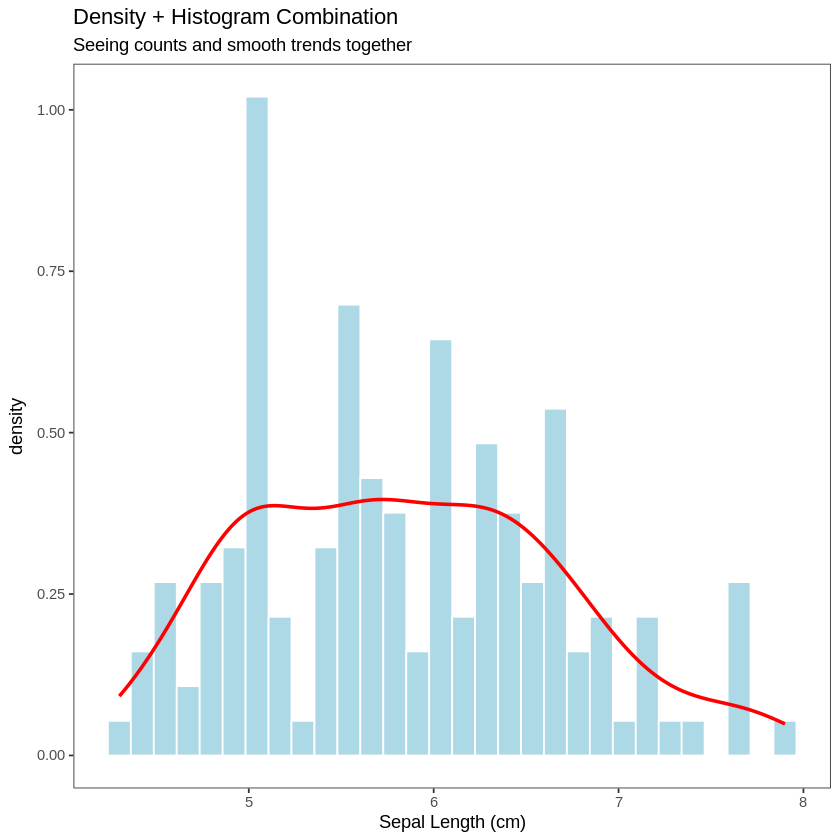

In [5]:
iris %>%
  ggplot(aes(Sepal.Length)) +
  # হিস্টোগ্রামের y অক্ষকে ডেনসিটি মোডে নেওয়া
  geom_histogram(aes(y = after_stat(density)),
                 bins = 30,
                 fill = "lightblue",
                 color = "white") +
  geom_density(color = "red", linewidth = 1) +
  theme_test() +
  labs(title = "Density + Histogram Combination",
       subtitle = "Seeing counts and smooth trends together",
       x = "Sepal Length (cm)")

**ব্যাখ্যা:** মনে রাখবেন, হিস্টোগ্রাম এবং ডেনসিটি একসাথে আঁকতে হলে হিস্টোগ্রামের y অক্ষে after_stat(density) (পুরানো ভার্সনে ..density..) ব্যবহার করতে হয়, নাহলে স্কেল মিলবে না।

#### এক নজরে আপনার শেখা টুলকিট:

- fill: এরিয়ার রঙ বদলাতে।
- alpha: স্বচ্ছতা নিয়ন্ত্রণ করতে।
- adjust: কার্ভের মসৃণতা ঠিক করতে।
- scale_fill_brewer(): প্রফেশনাল রঙের সেট ব্যবহার করতে।